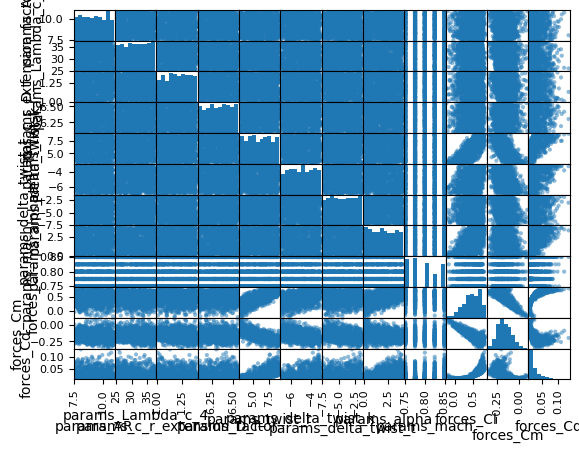

        AR  Lambda_c_4  c_r_extension_factor       D_f  twist_r  \
0   7.5535     28.2137                1.3658  6.146589   4.3664   
2   8.8473     35.3156                1.3404  6.485800   4.8286   
7   7.6918     31.1010                1.0560  6.296782   7.0987   
8   9.4110     25.2463                1.1231  6.238000   7.1201   
10  8.5056     29.3964                1.3494  6.233200   7.6767   

    delta_twist_k  delta_twist_t   alpha   mach        Cl        Cm        Cd  
0         -3.3671        -2.6924  2.4105  0.750  0.511728 -0.169879  0.023628  
2         -4.7202        -3.3240  3.7337  0.800  0.594720 -0.237627  0.027265  
7         -3.8480        -5.7325  2.8463  0.850  0.671283 -0.176352  0.060437  
8         -6.7700        -5.4939  1.3522  0.800  0.401594 -0.110122  0.018556  
10        -6.2323        -2.1093  2.8631  0.775  0.714791 -0.241313  0.038562  
9760
25.389461995268512
AR                       7.500000
Lambda_c_4              25.000000
c_r_extension_factor     

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

df = pd.read_csv("2025-10-29-full.csv")

data_cols = ["params_AR", "params_Lambda_c_4", "params_c_r_extension_factor", "params_D_f", 
             "params_twist_r", "params_delta_twist_k", "params_delta_twist_t", "params_alpha", "params_mach", 
             "forces_Cl", "forces_Cm", "forces_Cd"]

df_rel = df[data_cols]
df_rel = df_rel[df_rel["params_mach"] >= 0.75]

sample = df_rel.sample(n=1000)

scatter_matrix(sample, alpha=0.5)
plt.show()

df_rel_cols = ["AR", "Lambda_c_4", "c_r_extension_factor", "D_f", "twist_r", "delta_twist_k", "delta_twist_t", "alpha", "mach", "Cl", "Cm", "Cd"]
df_rel.columns = df_rel_cols

print(df_rel.head())
print(len(df_rel))

df_rel.to_csv("shift_wing_cleaned.csv", index=False)

ld = df["forces_Cl"] / df["forces_Cd"]
print(np.max(ld))

print(np.min(df_rel.iloc[:, :10], axis=0))
print(np.max(df_rel.iloc[:, :10], axis=0))

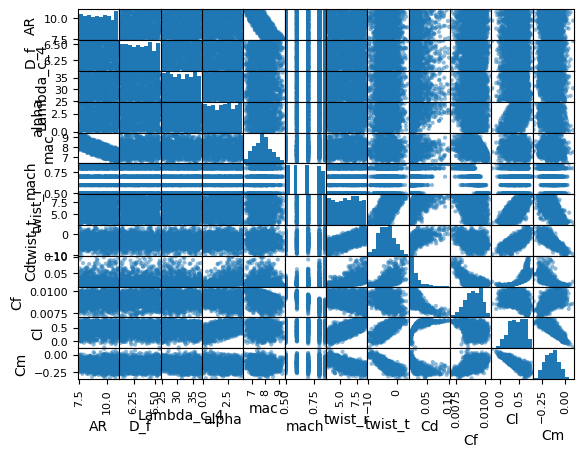

        AR       D_f  Lambda_c_4   alpha       mac  mach  twist_r  twist_t  \
0  10.3791  6.155555   31.951401  1.2856  6.719314   0.5   7.1435  -1.1096   
1   7.6924  6.478041   29.536501  3.3782  8.256662   0.5   4.3063  -4.8800   
2   9.3103  6.399832   34.210400  1.9221  7.245156   0.5   7.8176  -4.6582   
3   8.8847  6.199109   28.557100  3.0122  8.181735   0.5   6.0195  -2.5279   
4  10.9545  6.431135   33.155399  0.2751  6.878943   0.5   7.5377  -1.4090   

         Cd        Cf        Cl        Cm  
0  0.023114  0.010092  0.561629 -0.163966  
1  0.017173  0.009895  0.334455 -0.080622  
2  0.018772  0.010129  0.402427 -0.104525  
3  0.025662  0.009474  0.582227 -0.173435  
4  0.016660  0.010154  0.358907 -0.166517  
10359
25.389462
      feature        min        max
0          AR   7.500400  10.999500
1         D_f   6.096152   6.553200
2  Lambda_c_4  25.000700  37.496799
3       alpha   0.000400   3.999700
4         mac   6.425512   9.512536
5        mach   0.500000   0.850000

In [4]:
import json
from pathlib import Path

npz_path = Path("data.npz")
meta_path = Path("metadata.json")

loaded = np.load(npz_path)
if "X" in loaded and "y" in loaded:
    X = loaded["X"]
    y = loaded["y"]
else:
    raise ValueError("Expected data.npz to contain arrays named 'X' and 'y'")

with open(meta_path, "r") as f:
    meta = json.load(f)

feature_names = meta.get("feature_names", [])
target_names = meta.get("target_names", [])
reduced_features = meta.get("reduced_features", [])
reduced_targets = meta.get("reduced_targets", [])

if len(feature_names) != X.shape[1]:
    raise ValueError(
        f"Metadata feature length mismatch: {len(feature_names)} feature names != X columns {X.shape[1]}"
    )
if len(target_names) != y.shape[1]:
    raise ValueError(
        f"Metadata target length mismatch: {len(target_names)} target names != y columns {y.shape[1]}"
    )

feature_cols = feature_names
target_cols = target_names
all_col_names = feature_cols + target_cols

df_npz = pd.DataFrame(np.hstack([X, y]), columns=all_col_names)

selected_cols = reduced_features + reduced_targets
if not set(selected_cols).issubset(df_npz.columns):
    missing = set(selected_cols) - set(df_npz.columns)
    raise ValueError(f"Missing reduced columns in NPZ data: {missing}")

# Keep only reduced columns
if selected_cols:
    df_npz = df_npz[selected_cols]

sample = df_npz.sample(n=min(1000, len(df_npz)), random_state=42)
scatter_matrix(sample, alpha=0.5)
plt.show()

print(df_npz.head())
print(len(df_npz))

df_npz.to_csv("shift_wing_cleaned_from_npz.csv", index=False)


ld = df_npz["Cl"] / df_npz["Cd"]
print(np.max(ld))

if reduced_features:
    feature_bounds = pd.DataFrame(
        {
            "feature": reduced_features,
            "min": np.min(df_npz[reduced_features].values, axis=0),
            "max": np.max(df_npz[reduced_features].values, axis=0),
        }
    )
    print(feature_bounds)
